In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, KBinsDiscretizer
from sklearn.model_selection import StratifiedKFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.figure import Figure
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("../data/train_clear.csv")

In [3]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [4]:
cat_cols = X.select_dtypes(include="string").columns

numeric_cols = X.select_dtypes(include="number").columns
num_cols = [col for col in numeric_cols if len(df[col].unique()) > 2]

In [5]:
X_encoded = X.copy()

In [6]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=np.int64)
X_encoded[cat_cols] = encoder.fit_transform(X_encoded[cat_cols].to_numpy())

In [7]:
le = LabelEncoder()
y_encoded = np.array(le.fit_transform(y))

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

In [16]:
def train_model(model, X, y):
    all_y_true = []
    all_y_pred = []
    for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train.to_numpy(), y_train)

        y_pred = model.predict(X_val.to_numpy())
        
        score = model.score(X_val.to_numpy(), y_val)
        cv_scores.append(score)

        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)

    scores = np.array(cv_scores)
    print(f"Точность {model.__class__.__name__}: {scores.mean():0.3f} ± {scores.std():0.3f}")

    fig, ax = plt.subplots(figsize=(8, 6))
    disp_raw = ConfusionMatrixDisplay.from_predictions(
        all_y_true, 
        all_y_pred, 
        display_labels=le.classes_,
        ax=ax,
        normalize="true"
    )
    plt.xticks(rotation=45, ha='right')

Точность XGBClassifier: 0.877 ± 0.005


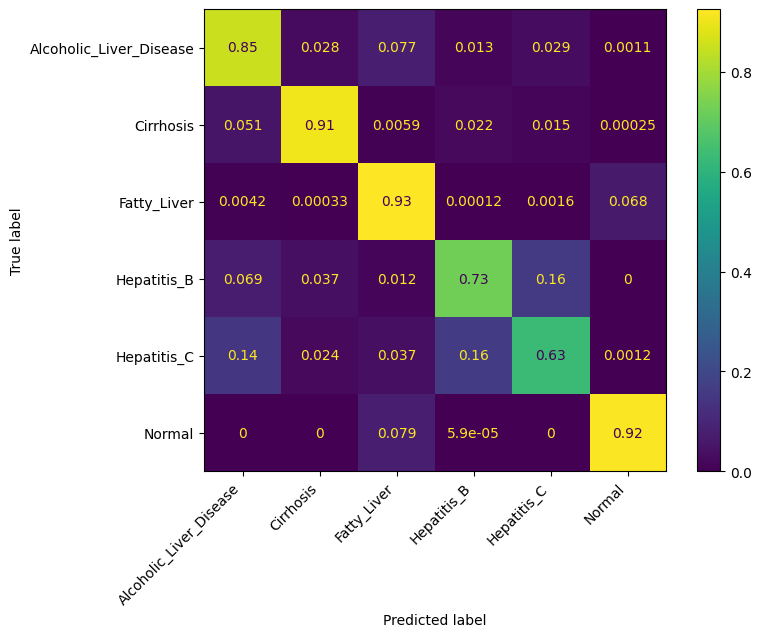

In [ ]:
# 8 секунд
xgb = XGBClassifier()
train_model(xgb, X_encoded, y_encoded)

In [18]:
importance_df = pd.DataFrame(
    {"feature": X_encoded.columns, "importance": xgb.feature_importances_}
).sort_values("importance", ascending=False)

print(importance_df.head(20))

                   feature  importance
14             Sym_Ascites    0.184641
10             Sym_Fatigue    0.165295
15          Sym_Dark_Urine    0.134934
11            Sym_Jaundice    0.108477
20                     ALT    0.070292
21                     AST    0.050860
22               Bilirubin    0.050426
17         Comorb_Diabetes    0.043423
12      Sym_Abdominal_Pain    0.039907
13             Sym_Itching    0.032892
23                 Albumin    0.029918
16         Sym_Weight_Loss    0.023400
24               Platelets    0.018300
19  Comorb_Genetic_History    0.007967
27          De_Ritis_ratio    0.003803
18     Comorb_Hypertension    0.003112
9      Alcohol_Consumption    0.003098
2               Occupation    0.003095
3                      BMI    0.003089
7              Sleep_Hours    0.003056


Точность GradientBoostingClassifier(): 0.869 ± 0.003


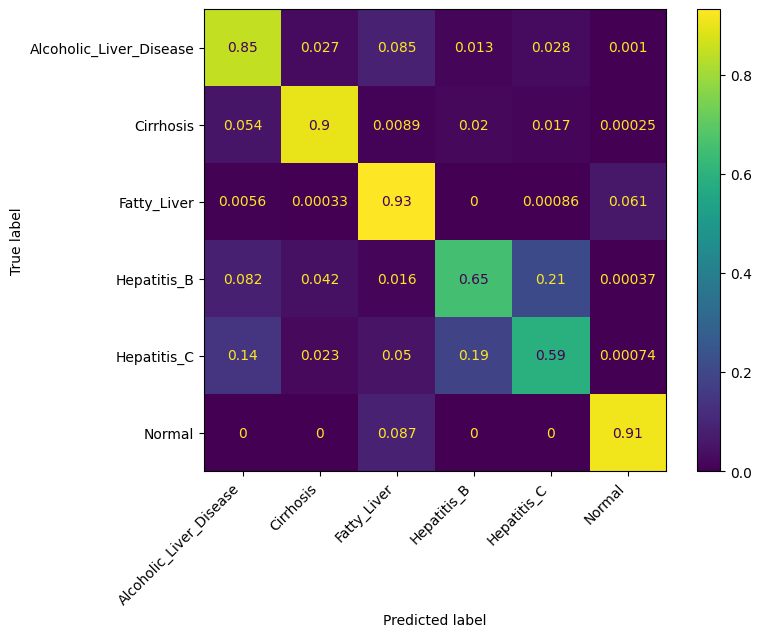

In [ ]:
# 7 минут
grad_boost = GradientBoostingClassifier()
train_model(grad_boost, X_encoded, y_encoded)

In [19]:
importance_df = pd.DataFrame(
    {"feature": X_encoded.columns, "importance": grad_boost.feature_importances_}
).sort_values("importance", ascending=False)

print(importance_df.head(20))

                   feature  importance
20                     ALT    0.221235
22               Bilirubin    0.196924
21                     AST    0.156802
23                 Albumin    0.074373
10             Sym_Fatigue    0.072951
11            Sym_Jaundice    0.069660
15          Sym_Dark_Urine    0.063561
14             Sym_Ascites    0.058153
24               Platelets    0.036353
17         Comorb_Diabetes    0.023048
12      Sym_Abdominal_Pain    0.012661
13             Sym_Itching    0.008182
16         Sym_Weight_Loss    0.004180
19  Comorb_Genetic_History    0.000571
27          De_Ritis_ratio    0.000501
3                      BMI    0.000302
0                      Age    0.000149
2               Occupation    0.000107
7              Sleep_Hours    0.000107
25         Alk_Phosphatase    0.000055
